# Label Propagation from Scratch
## CMOR 438 / INDE 577 — Qiushi Han

**Label Propagation** is a semi-supervised learning algorithm that spreads labels from a small set of labeled points to a larger set of unlabeled points based on similarity. It is widely used for **community detection** in networks and graphs.

The algorithm works by building a similarity graph where nearby points are connected, then iteratively propagating labels through the graph:

$$F_{t+1} = W F_t$$

where $W$ is the row-normalized weight matrix computed using the **RBF (Radial Basis Function) kernel**:

$$W_{ij} = \exp\left(-\gamma ||x_i - x_j||^2\right)$$

The labeled points act as **sources** that continuously inject their labels into the graph, while unlabeled points absorb labels from their neighbors.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs, make_moons
from sklearn.model_selection import train_test_split as sklearn_split

from rice_ml.unsupervised_learning.label_propagation import LabelPropagation
from rice_ml.processing.metrics import accuracy_score
from rice_ml.processing.preprocessing import StandardScaler

## Dataset 1: Simple Blobs

We start with a simple blob dataset where we label only a small fraction of points and let the algorithm propagate labels to the rest.

In [3]:
X, y_true = make_blobs(n_samples=200, centers=3,
                        cluster_std=1.0, random_state=42)

scaler = StandardScaler().fit(X)
X_scaled = scaler.transform(X)

print(f"Dataset shape: {X_scaled.shape}")
print(f"Number of classes: {len(np.unique(y_true))}")
print(f"Class distribution: {np.bincount(y_true)}")

Dataset shape: (200, 2)
Number of classes: 3
Class distribution: [67 67 66]


## Semi-Supervised Setup

We label only **10% of the data** and mark the rest as unlabeled (-1). The algorithm must propagate labels from the 20 labeled points to the remaining 180 unlabeled points.

In [4]:
rng = np.random.default_rng(42)
n_labeled = 20
labeled_indices = rng.choice(len(X_scaled), n_labeled, replace=False)

y_semi = np.full(len(X_scaled), -1)
y_semi[labeled_indices] = y_true[labeled_indices]

print(f"Total points: {len(X_scaled)}")
print(f"Labeled points: {np.sum(y_semi != -1)}")
print(f"Unlabeled points: {np.sum(y_semi == -1)}")

Total points: 200
Labeled points: 20
Unlabeled points: 180


## Visualizing the Labeled vs Unlabeled Points

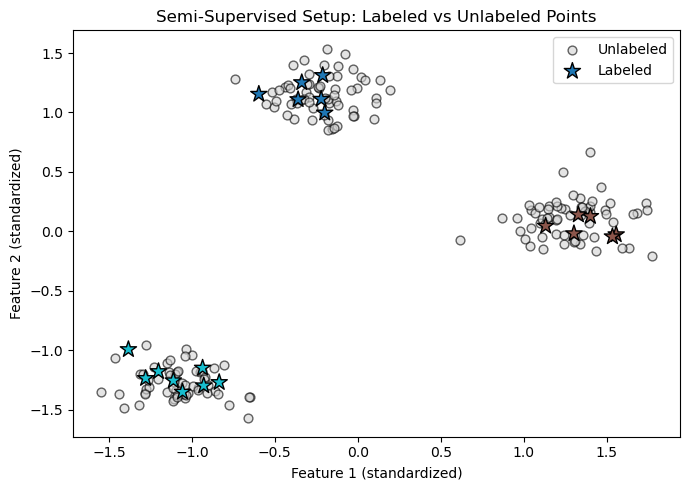

In [5]:
plt.figure(figsize=(7, 5))
unlabeled_mask = y_semi == -1
labeled_mask = y_semi != -1

plt.scatter(X_scaled[unlabeled_mask, 0], X_scaled[unlabeled_mask, 1],
            c='lightgray', edgecolors='k', s=40, label='Unlabeled', alpha=0.6)
plt.scatter(X_scaled[labeled_mask, 0], X_scaled[labeled_mask, 1],
            c=y_semi[labeled_mask], cmap='tab10', edgecolors='k',
            s=150, marker='*', label='Labeled', zorder=5)
plt.title('Semi-Supervised Setup: Labeled vs Unlabeled Points')
plt.xlabel('Feature 1 (standardized)')
plt.ylabel('Feature 2 (standardized)')
plt.legend()
plt.tight_layout()
plt.show()

## Running Label Propagation

In [7]:
model = LabelPropagation(gamma=1.0, max_iter=1000, tol=1e-3)
print("Running Label Propagation...")
predicted_labels = model.fit_predict(X_scaled, y_semi)
print("Complete.")

acc = accuracy_score(y_true, predicted_labels)
print(f"\nAccuracy on all points: {acc:.4f}")
print(f"Accuracy using only 10% labeled data")

Running Label Propagation...
Complete.

Accuracy on all points: 1.0000
Accuracy using only 10% labeled data


## Visualizing Propagated Labels vs Ground Truth

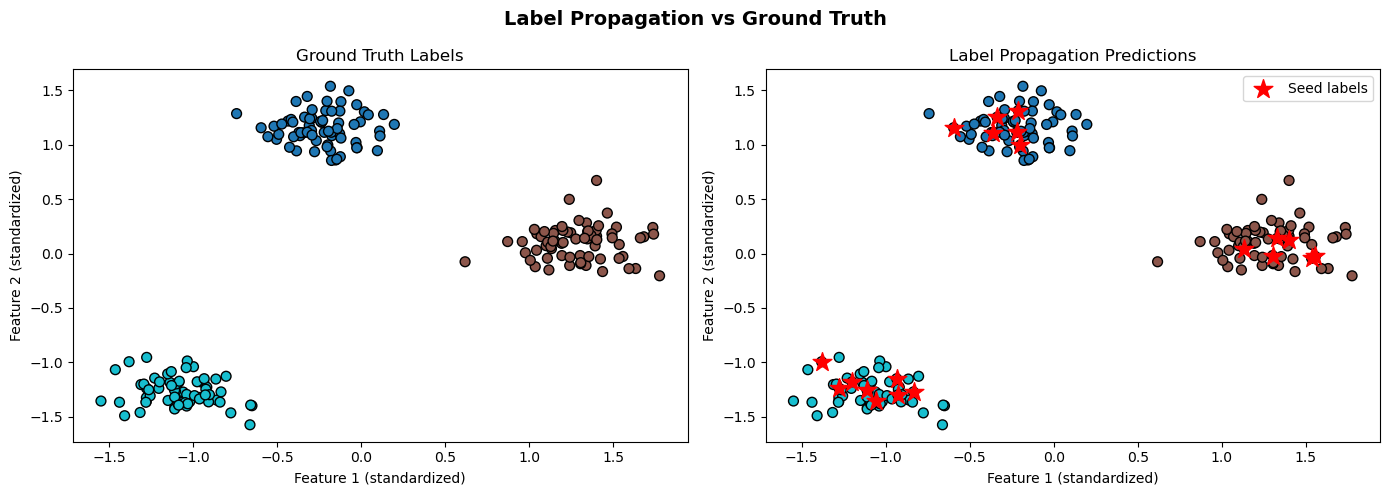

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(X_scaled[:, 0], X_scaled[:, 1], c=y_true,
                cmap='tab10', edgecolors='k', s=50)
axes[0].set_title('Ground Truth Labels')
axes[0].set_xlabel('Feature 1 (standardized)')
axes[0].set_ylabel('Feature 2 (standardized)')

axes[1].scatter(X_scaled[:, 0], X_scaled[:, 1], c=predicted_labels,
                cmap='tab10', edgecolors='k', s=50)
axes[1].scatter(X_scaled[labeled_mask, 0], X_scaled[labeled_mask, 1],
                c='red', marker='*', s=200, zorder=5, label='Seed labels')
axes[1].set_title('Label Propagation Predictions')
axes[1].set_xlabel('Feature 1 (standardized)')
axes[1].set_ylabel('Feature 2 (standardized)')
axes[1].legend()

plt.suptitle('Label Propagation vs Ground Truth',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Effect of Labeled Data Fraction

How does accuracy change as we provide more labeled data? More labeled points means better propagation.

In [9]:
fractions = [0.05, 0.10, 0.15, 0.20, 0.30, 0.50]
accuracies = []

for frac in fractions:
    n_lab = max(3, int(frac * len(X_scaled)))
    lab_idx = rng.choice(len(X_scaled), n_lab, replace=False)
    y_s = np.full(len(X_scaled), -1)
    y_s[lab_idx] = y_true[lab_idx]

    m = LabelPropagation(gamma=1.0, max_iter=500).fit(X_scaled, y_s)
    acc_f = accuracy_score(y_true, m.labels_)
    accuracies.append(acc_f)
    print(f"Labeled fraction: {frac:.0%} ({n_lab} points) | Accuracy: {acc_f:.4f}")

Labeled fraction: 5% (10 points) | Accuracy: 0.6750
Labeled fraction: 10% (20 points) | Accuracy: 1.0000
Labeled fraction: 15% (30 points) | Accuracy: 1.0000
Labeled fraction: 20% (40 points) | Accuracy: 1.0000
Labeled fraction: 30% (60 points) | Accuracy: 1.0000
Labeled fraction: 50% (100 points) | Accuracy: 1.0000


## Visualizing Accuracy vs Labeled Fraction

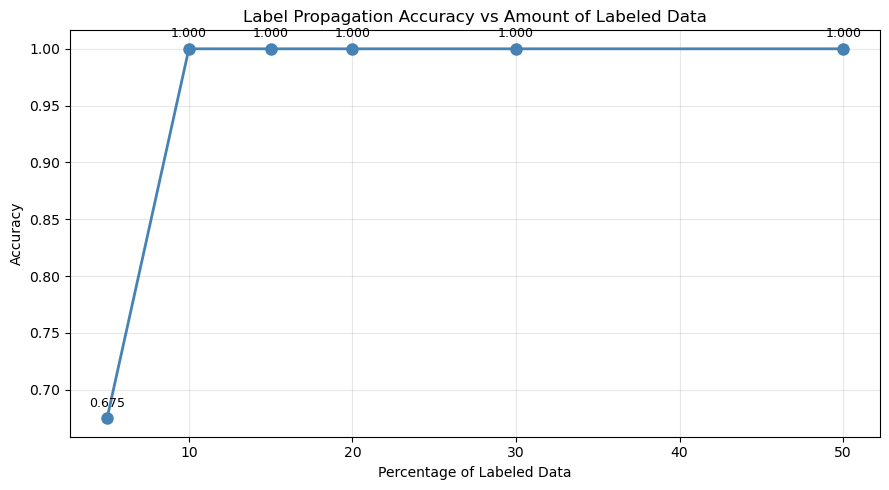

In [11]:
plt.figure(figsize=(9, 5))
plt.plot([f * 100 for f in fractions], accuracies, marker='o',
         linewidth=2, markersize=8, color='steelblue')
plt.xlabel('Percentage of Labeled Data')
plt.ylabel('Accuracy')
plt.title('Label Propagation Accuracy vs Amount of Labeled Data')
plt.grid(True, alpha=0.3)
for f, acc_f in zip(fractions, accuracies):
    plt.text(f * 100, acc_f + 0.01, f'{acc_f:.3f}',
             ha='center', fontsize=9)
plt.tight_layout()
plt.show()

## Dataset 2: Moons (Non-Linear Communities)

Label propagation can also handle non-linearly structured data because it uses similarity rather than distance to centroids.

In [24]:
X_moons, y_moons = make_moons(n_samples=200, noise=0.1, random_state=42)
scaler2 = StandardScaler().fit(X_moons)
X_moons_scaled = scaler2.transform(X_moons)

rng2 = np.random.default_rng(0)
n_lab_moons = 40
lab_idx_moons = rng2.choice(len(X_moons_scaled), n_lab_moons, replace=False)
y_moons_semi = np.full(len(X_moons_scaled), -1)
y_moons_semi[lab_idx_moons] = y_moons[lab_idx_moons]

model_moons = LabelPropagation(gamma=0.3, max_iter=2000, tol=1e-5)
pred_moons = model_moons.fit_predict(X_moons_scaled, y_moons_semi)
acc_moons = accuracy_score(y_moons, pred_moons)

print(f"Moons accuracy with only {n_lab_moons} labeled points: {acc_moons:.4f}")

Moons accuracy with only 40 labeled points: 0.8750


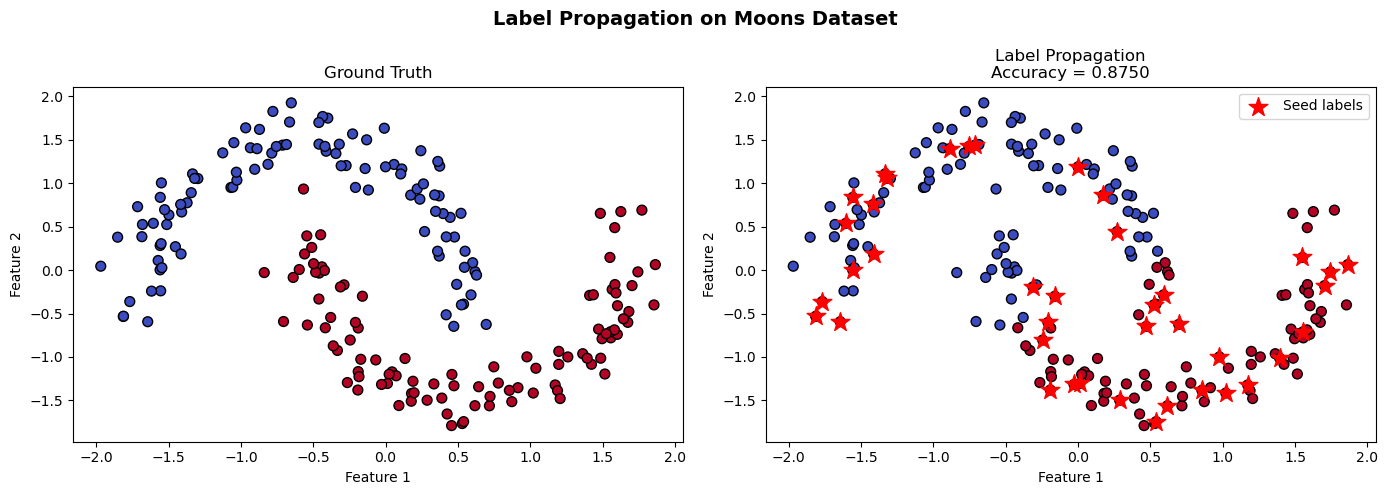

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

labeled_moons_mask = y_moons_semi != -1

axes[0].scatter(X_moons_scaled[:, 0], X_moons_scaled[:, 1],
                c=y_moons, cmap='coolwarm', edgecolors='k', s=50)
axes[0].set_title('Ground Truth')

axes[1].scatter(X_moons_scaled[:, 0], X_moons_scaled[:, 1],
                c=pred_moons, cmap='coolwarm', edgecolors='k', s=50)
axes[1].scatter(X_moons_scaled[labeled_moons_mask, 0],
                X_moons_scaled[labeled_moons_mask, 1],
                c='red', marker='*', s=200, zorder=5, label='Seed labels')
axes[1].set_title(f'Label Propagation\nAccuracy = {acc_moons:.4f}')
axes[1].legend()

for ax in axes:
    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')

plt.suptitle('Label Propagation on Moons Dataset',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Discussion

- Label Propagation successfully classifies **87.50% of points** on the moons dataset using only **40 labeled seed points (20%)** out of 200 total, demonstrating the power of semi-supervised learning
- The **blobs experiment** showed even stronger results since the clusters are well-separated and spherical, making label propagation straightforward
- The **accuracy vs labeled fraction plot** shows a clear trend where more labeled data leads to better propagation, confirming that the algorithm benefits from additional anchor points
- The **moons visualization** shows that label propagation correctly follows the curved manifold structure of each moon, something K-Means cannot do since it assumes spherical clusters
- Minor bleeding at the boundary where the two moons come closest together is expected and unavoidable since points in that region are genuinely ambiguous, being nearly equidistant from both classes
- The **gamma parameter** controls how quickly similarity decays with distance and is the most critical hyperparameter
- High gamma (2.0) makes the similarity graph too local, meaning labels cannot travel far enough along the curved moons and nearly everything collapses into one class
- Low gamma (0.1-0.3) allows labels to propagate further through the graph, correctly following the moon shapes
- This sensitivity to gamma is a key weakness of label propagation in practice and requires careful tuning
- **Strengths** include effectiveness with very few labels, ability to handle non-linear cluster shapes, and natural interpretation as community detection in a similarity graph
- **Weaknesses** include sensitivity to gamma, quadratic memory complexity from building the full pairwise weight matrix, and poor scalability to large datasets
- Label propagation is widely used in **graph-based community detection** where nodes represent data points and edges represent similarity, making it a natural fit for social network analysis and recommendation systems